# 12_时间序列分析方法-Holt-Winters

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们介绍一下时间序列中，一个非常常用的算法模型，Holt-Winters！

首先，时间序列模型是一种用来分析和预测一段时间内数据变化的数学模型。

简单来说，就是根据过去的数据趋势，来推测未来的数据。比如，你想预测未来几天的气温，股票价格，或者公司销量，都可以用时间序列模型。

时间序列模型可以分为：

- **平稳模型（如AR、MA、ARMA）**：适用于数据趋势比较稳定的情况。
- **非平稳模型（如ARIMA）**：适用于有趋势变化的情况。
- **季节性模型（如Holt-Winters）**：适用于数据有周期性变化，比如每年某些月份的销量特别高。

#### 那么Holt-Winters 模型具体是什么

Holt-Winters 是一种可以处理 **趋势和季节性** 的时间序列预测模型。它适用于数据有明显增长/下降趋势，且有周期性波动的情况，比如：

- 电商销量（双11、春节前后会有波动）
- 气温变化（夏天高、冬天低）
- 交通流量（工作日 vs 周末）

**Holt-Winters 主要分为两种：**

1. 加法模型（适用于季节性变化幅度比较稳定的情况）
2. 乘法模型（适用于季节性变化幅度会随着数据增大或减小的情况）

## Holt-Winters 公式

Holt-Winters 模型主要有三个核心部分：

1. **水平值（Level）**：表示当前数据的整体水平。  
$L_t = \alpha (Y_t / S_{t-s}) + (1-\alpha) (L_{t-1} + T_{t-1})$
2. **趋势（Trend）**：表示数据增长或减少的趋势。  
$T_t = \beta (L_t - L_{t-1}) + (1-\beta) T_{t-1}$
3. **季节性（Seasonality）**：表示周期性变化的影响。  
$S_t = \gamma (Y_t / L_t) + (1 - \gamma) S_{t-s}$

最终的预测值：


$$
\hat{Y}_{t+h} = (L_t + hT_t) S_{t+h-s}
$$


其中：

- $Y_t$：实际观测值
- $L_t$：水平值
- $T_t$：趋势值
- $S_t$：季节性因素
- $s$：季节周期长度（比如一年12个月，s=12）
- $\alpha, \beta, \gamma$是平滑参数，取值范围 $(0,1)$

### 一个案例

假设我们有一家冰淇淋店，想预测未来的销售量。

我们发现：

- **每年夏天（6\~8月）销量特别高**
- **冬天销量特别低**
- **整体趋势是逐年上升**

我们用 **Holt-Winters 加法模型** 来预测未来的销量。

#### 假设数据

| 月份 | 销量（单位：支） |
|-|-|
| 1月 | 200 |
| 2月 | 180 |
| 3月 | 220 |
| 4月 | 250 |
| 5月 | 270 |
| 6月 | 400 |
| 7月 | 500 |
| 8月 | 480 |
| 9月 | 300 |
| 10月 | 260 |
| 11月 | 230 |
| 12月 | 210 |

**计算步骤**

1. **计算初始水平值（L0）**：可以取前几个月的均值。  
$L_0 = \frac{200 + 180 + 220 + 250}{4} = 212.5$
2. **计算趋势值（T0）**：用相邻几个月的平均变化率。  
$T_0 = \frac{(250 - 200) + (270 - 220) + (400 - 250)}{3} = 66.67$
3. **计算季节性因素（S）**：可以用每月数据相对均值的比值，比如 6 月的季节因子：  
$S_6 = \frac{400}{L_0} = \frac{400}{212.5} \approx 1.88$

**预测下一年 6 月销量**

假设 $\alpha = 0.5$，$\beta = 0.3$，$\gamma = 0.2$，计算：  
$L_1 = 0.5 \times \frac{400}{S_6} + (1-0.5) \times (L_0 + T_0) = 0.5 \times \frac{400}{1.88} + 0.5 \times (212.5 + 66.67)$  
$= 0.5 \times 212.77 + 0.5 \times 279.17 = 106.39 + 139.58 = 245.97$

$T_1 = 0.3 \times (L_1 - L_0) + (1-0.3) \times T_0 = 0.3 \times (245.97 - 212.5) + 0.7 \times 66.67$  
$= 0.3 \times 33.47 + 0.7 \times 66.67 = 10.04 + 46.67 = 56.71$

$S_7 = 0.2 \times \frac{500}{L_1} + (1-0.2) \times S_6 = 0.2 \times \frac{500}{245.97} + 0.8 \times 1.88$  
$= 0.2 \times 2.03 + 0.8 \times 1.88 = 0.41 + 1.50 = 1.91$

最终预测 2024 年 6 月销量：  
$Y_{t+6} = (L_1 + 6T_1) S_7$  
$= (245.97 + 6 \times 56.71) \times 1.91$  
$= (245.97 + 340.26) \times 1.91$  
$= 586.23 \times 1.91 = 1119.69$

**预测结果：明年 6 月销量大约是 1120 支冰淇淋。**

## 公式解析

**Holt-Winters 核心思想是通过** 平滑处理过去的数据，以计算出当前时间的水平值、趋势和季节性成分，然后用于预测未来值。

### 1. Holt-Winters 方法

Holt-Winters 方法包含三种主要成分：

1. **水平值（Level,** $L_t$**）**：数据的基本水平。
2. **趋势（Trend,** $T_t$**）**：数据的增长或衰减趋势。
3. **季节性（Seasonality,** $S_t$**）**：数据的周期性波动。

根据季节性成分的计算方式，Holt-Winters 方法可以分为：

- **加法模型（适用于季节性幅度较稳定的情况）**
- **乘法模型（适用于季节性变化幅度随数据增大或减小的情况）**

### 2. Holt-Winters 加法模型

适用于季节性变化幅度相对稳定的情况，即：


$$
Y_t = L_t + T_t + S_{t-s} + \epsilon_t
$$


其中：

- $Y_t$是时间 $t$时刻的观测值
- $L_t$是时间 $t$时刻的平滑水平值
- $T_t$是时间 $t$时刻的趋势项
- $S_{t-s}$是上一个相同季节周期的季节性成分（周期长度为 $s$）
- $\epsilon_t$是随机误差项

#### 2.1 计算水平值

水平值的更新公式：


$$
L_t = \alpha (Y_t - S_{t-s}) + (1 - \alpha)(L_{t-1} + T_{t-1})
$$


- 其中 $\alpha$是水平平滑系数（0 到 1 之间）
- 公式的第一部分 $\alpha (Y_t - S_{t-s})$表示当前观测值去除季节性影响后的加权贡献
- 公式的第二部分 $(1 - \alpha)(L_{t-1} + T_{t-1})$代表前一期的趋势和水平的贡献

#### 2.2 计算趋势项

趋势项的更新公式：


$$
T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1}
$$


- 其中 $\beta$是趋势平滑系数（0 到 1 之间）
- 公式的第一部分 $\beta (L_t - L_{t-1})$表示当前水平值变化的加权贡献
- 公式的第二部分 $(1 - \beta) T_{t-1}$代表过去趋势的影响

#### 2.3 计算季节性项


$$
S_t = \gamma (Y_t - L_t) + (1 - \gamma) S_{t-s}
$$


- 其中 $\gamma$是季节性平滑系数（0 到 1 之间）
- 公式的第一部分 $\gamma (Y_t - L_t)$代表当前周期的季节性影响
- 公式的第二部分 $(1 - \gamma) S_{t-s}$代表过去周期的季节性影响

#### 2.4 预测公式

未来 $h$步预测值：


$$
\hat{Y}_{t+h} = L_t + h T_t + S_{t+h-s}
$$


- $L_t$是当前水平值
- $h T_t$是趋势项的影响
- $S_{t+h-s}$是对应季节周期的季节性项

### 3. Holt-Winters 乘法模型

适用于季节性幅度随整体水平增长或减少的情况：


$$
Y_t = (L_t + T_t) S_{t-s} + \epsilon_t
$$


其中：

- 季节性成分是数据的乘法因子，而不是加法因子

#### 3.1. 计算水平值


$$
L_t = \alpha \frac{Y_t}{S_{t-s}} + (1 - \alpha)(L_{t-1} + T_{t-1})
$$


- 这里用 $Y_t / S_{t-s}$进行归一化，以减少季节性影响

#### 3.2. 计算趋势项


$$
T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1}
$$


- 计算方式与加法模型相同

#### 3.3. 计算季节性项


$$
S_t = \gamma \frac{Y_t}{L_t} + (1 - \gamma) S_{t-s}
$$


- 季节性因子使用乘法形式进行归一化

#### 3.4. 预测公式


$$
\hat{Y}_{t+h} = (L_t + hT_t) S_{t+h-s}
$$


### 4. 公式推导

以 **加法模型** 为例，推导预测值的计算方式。

#### 4.1. 递推公式

从基本公式：

$L_t = \alpha (Y_t - S_{t-s}) + (1 - \alpha)(L_{t-1} + T_{t-1})$  
$T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1}$  
$S_t = \gamma (Y_t - L_t) + (1 - \gamma) S_{t-s}$

对于未来的预测值：


$$
\hat{Y}_{t+h} = L_t + h T_t + S_{t+h-s}
$$


假设数据增长趋势是线性的，则可以展开：

$\hat{Y}_{t+h} = (\alpha (Y_t - S_{t-s}) + (1 - \alpha)(L_{t-1} + T_{t-1})) + h (\beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1}) + S_{t+h-s}$  
$= \alpha Y_t - \alpha S_{t-s} + (1 - \alpha)L_{t-1} + (1 - \alpha)T_{t-1} + h\beta (L_t - L_{t-1}) + h(1 - \beta)T_{t-1} + S_{t+h-s}$

如果 $h = s$（预测一个完整周期后的值），那么：


$$
\hat{Y}_{t+s} = L_t + s T_t + S_t
$$


这一点表明，未来的值是由当前水平、趋势、以及相应季节性因子决定的。

总结来看，Holt-Winters 方法通过**指数平滑**技术，对**水平、趋势、季节性**进行分解，并递推计算未来值。

- **加法模型** 适用于季节性变化幅度固定的数据。
- **乘法模型** 适用于季节性变化随整体水平增长的数据。
- 通过递推公式，可以对未来多个周期进行预测，并且可以通过调整参数 $\alpha, \beta, \gamma$影响预测结果。

## 完整案例

咱们这里基于冰淇淋销量的案例，利用 Holt-Winters 加法模型对数据进行拟合、预测\~

代码中给到大家原始数据、拟合结果、未来预测、季节性分量以及残差分析，同时也对数据进行了详细的解释与分析。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_10234/3214385106.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_rng = pd.date_range(start='2023-01-01', periods=36, freq='M')
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_10234/3214385106.py:28: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  hw_fit = model.fit(smoothing_level=0.8, smoothing_slope=0.2, smoothing_seasonal=0.2)


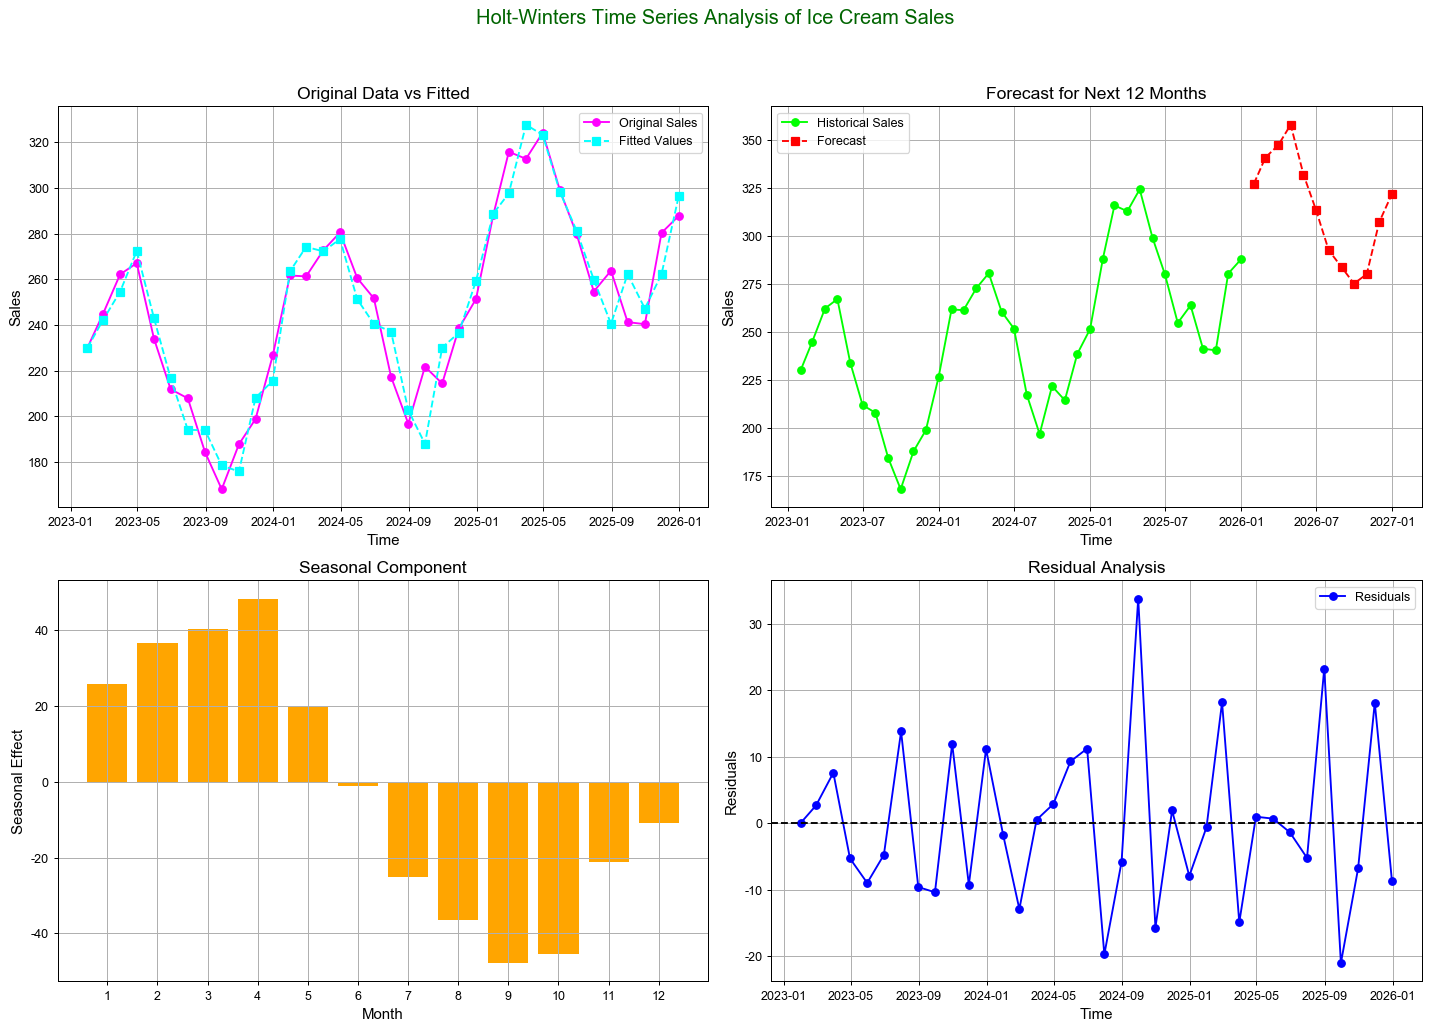

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)

# 生成 3 年（36 个月）的月度数据
date_rng = pd.date_range(start='2023-01-01', periods=36, freq='M')

# 构造冰淇淋销售数据：
# 1. 趋势项：从 200 到 300 线性增加，模拟逐渐增长的市场趋势
# 2. 季节性：利用月份信息构造季节性波动，使用正弦函数模拟每年夏季销量上升、冬季下降
# 3. 噪声：加入正态分布噪声，使数据更贴近真实情况
trend = np.linspace(200, 300, 36)  # 趋势项
seasonality = 50 * np.sin(2 * np.pi * date_rng.month / 12)  # 季节性项：幅度为50
noise = np.random.normal(0, 10, 36)  # 噪声项，标准差为10
sales = trend + seasonality + noise

# 构造 DataFrame，索引为日期
data = pd.DataFrame({'Date': date_rng, 'Sales': sales})
data.set_index('Date', inplace=True)

# 模型拟合：Holt-Winters 加法模型
# 使用 Holt-Winters 加法模型进行拟合，指定趋势和季节性均为加法形式
# seasonal_periods=12 表示季节周期为 12 个月
model = ExponentialSmoothing(data['Sales'], trend='add', seasonal='add', seasonal_periods=12)
hw_fit = model.fit(smoothing_level=0.8, smoothing_slope=0.2, smoothing_seasonal=0.2)

# 预测未来 12 个月数据
forecast = hw_fit.forecast(12)

# 计算模型拟合的残差：实际值减去拟合值
fitted_values = hw_fit.fittedvalues
residuals = data['Sales'] - fitted_values

# 获取模型提取的季节性分量（取最后一个周期的季节性系数）
seasonal_component = hw_fit.season[-12:]

# 数据分析图像
plt.figure(figsize=(16, 12))

# 子图 1：原始数据与拟合曲线对比
plt.subplot(2, 2, 1)
plt.plot(data.index, data['Sales'], 'o-', color='magenta', label='Original Sales')
plt.plot(data.index, fitted_values, 's--', color='cyan', label='Fitted Values')
plt.title('Original Data vs Fitted', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True)

# 子图 2：未来 12 个月预测结果
plt.subplot(2, 2, 2)
plt.plot(data.index, data['Sales'], 'o-', color='lime', label='Historical Sales')
plt.plot(forecast.index, forecast, 's--', color='red', label='Forecast')
plt.title('Forecast for Next 12 Months', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True)

# 子图 3：季节性分量分析
plt.subplot(2, 2, 3)
months = np.arange(1, 13)
plt.bar(months, seasonal_component, color='orange')
plt.title('Seasonal Component', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Seasonal Effect', fontsize=12)
plt.xticks(months)
plt.grid(True)

# 子图 4：残差分析
plt.subplot(2, 2, 4)
plt.plot(data.index, residuals, 'o-', color='blue', label='Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle('Holt-Winters Time Series Analysis of Ice Cream Sales', fontsize=16, color='darkgreen')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

通过 `ExponentialSmoothing` 类构造 Holt-Winters 模型，并对数据进行拟合。

拟合后模型不仅生成了每个月的平滑水平、趋势以及季节性分量，同时利用这些信息预测了未来 12 个月的冰淇淋销量。

- **拟合结果**：通过模型计算得到的拟合值能够平滑原始数据中的噪声，并将趋势和季节性有效分解，使得模型对数据的描述更为精确。
- **预测结果**：利用当前时刻的模型状态，预测未来 12 个月的销量。由于 Holt-Winters 模型是基于递归的平滑方法，短期内预测准确度较高，但长期预测可能会因误差累积而出现偏差。

![原文参考图，当前结果见代码输出](attachments/img_027.png)

**图 1：Original Data vs Fitted**：展示了原始冰淇淋销量数据（用 magenta 色圆点和线条表示）与模型拟合后的平滑曲线（用 cyan 色方块和虚线表示）。通过对比原始数据与拟合值，我们可以直观地看到模型在捕捉数据趋势和季节性方面的效果。若两者拟合较好，说明模型参数设定合理，能够较好地反映数据的真实变化情况。模型对数据进行了指数平滑处理，平滑后数据剔除了短期波动的噪声，从而更突出趋势和季节性。

**图 2：Forecast for Next 12 Months**：此子图一方面绘制了历史冰淇淋销量数据（用 lime 颜色标示），另一方面展示了未来 12 个月的预测数据（用 red 色标示，带有方块和虚线）。通过预测结果可以了解未来一年的销量趋势，尤其是在季节性波动的基础上，如何延续现有的增长趋势。这对于企业决策、库存管理以及市场调控都具有重要参考价值。预测利用了当前的平滑水平、趋势和季节性分量，并结合递归计算得到未来的数据点，模型能够很好地延续历史数据的特征，但长期预测时需注意误差积累的问题。

**图 3：Seasonal Component**：该子图以条形图的形式展示了模型提取的季节性分量，横坐标代表月份（1 至 12），条形图的高度反映了每个月的季节性效应。通过分析季节性分量，我们可以发现不同月份对整体销量的贡献。比如，如果夏季的季节性因子较高，则说明夏季销量在整体数据中占比较大，企业可以在夏季加大库存和促销力度。模型在拟合过程中利用每个周期内的历史数据提取出季节性影响，条形图直观地反映了这一影响力度，为市场分析提供了依据。

**图 4：Residual Analysis**：残差图显示了实际数据与模型拟合数据之间的差异，使用 blue 色圆点和线条展示，并绘制了一条黑色虚线（y=0），以便观察残差是否围绕 0 分布。残差分析是检验模型有效性的重要手段。理想情况下，残差应随机分布且均值接近 0，表明模型捕捉了数据中的所有显著信息；若存在明显的模式或趋势，则表明模型尚未完全解释数据的全部特征。残差的计算为实际值减去拟合值，检测残差分布可以帮助判断是否需要进一步优化模型或引入其他外生变量。

## 优缺点和适用场景

### 优点

1. **适用于趋势+季节性数据**：适用于具有 **长期增长趋势** 和 **周期性波动** 的数据，如销售量、气温、网站流量等。
2. **计算简单、易于实现**：计算量较小，不需要大量历史数据，也不需要复杂的优化算法（相比 ARIMA、LSTM）。
3. **实时更新，适用于在线预测**：由于是递归计算，每次新数据到来时可以快速更新模型，适用于 **实时预测场景**。
4. **平滑处理数据，减少噪声影响**：采用指数平滑技术，能够减少短期波动带来的干扰，提高预测的稳定性。
5. **可调节参数灵活**：通过调整 **平滑参数（**$\alpha, \beta, \gamma$**）**，可以控制对历史数据的依赖程度，使模型适应不同类型的时间序列。

### 缺点

1. **对参数敏感，手动调参困难**：需要调整 $\alpha, \beta, \gamma$ 三个平滑系数，不同数据集可能需要不同的参数，手动调参较难。
2. **无法处理非线性复杂趋势**：只能处理 **线性增长趋势**，如果数据存在 **非线性趋势**（如指数增长或衰减），Holt-Winters 可能无法很好地拟合。
3. **对突发变化敏感，难以应对异常情况**：例如，突发的市场变化、极端天气、疫情等异常事件，Holt-Winters 可能无法快速适应。
4. **季节周期必须已知并固定**：需要**预先设定季节性周期长度**（如 12 个月、7 天等），如果数据的季节性变化是动态的，该方法无法自动调整。
5. **长期预测效果较差**：由于 Holt-Winters 采用**递归计算**，短期预测效果好，但长期预测时，误差会不断积累，导致预测偏差增大。

### 适用场景

1. 业务销售预测：例如，电商销量预测（如双11、黑五等促销季节）
2. 气象数据预测：例如，气温预测（夏天高、冬天低，存在周期性变化）
3. 供应链与库存管理：例如，预测未来库存需求（某些商品的需求具有周期性，如节假日商品）
4. 交通流量预测：例如，地铁客流量预测（早晚高峰 vs 非高峰）
5. 网站流量与用户行为预测：例如，网站访问量预测（如节假日、促销活动期间流量上涨）
6. 金融市场预测（适用于某些情况下）：例如，股票市场的季节性模式（但股票市场通常受多种因素影响，Holt-Winters 不能很好处理非线性变化）

### 不适用场景

- **数据没有季节性**（Holt-Winters 专门用于有季节性的时间序列）
- **数据趋势是非线性的**（例如指数增长、对数衰减等）
- **存在突发事件或异常值较多**（疫情、战争等外部因素影响）
- **需要长期预测**（短期预测较准，但长期预测误差积累较快）
- **季节性周期是变化的**（如动态调整的促销策略，Holt-Winters 无法自适应）

## 最后

整个内容，咱们通过模拟冰淇淋销量数据，从数据生成、模型建立、拟合预测到结果可视化，全流程展示了 Holt-Winters 时间序列模型在实际业务中的应用过程。